# Top embeddings: leave-one-use-case-out, prediction-level stacking, calibration

Follow-up to `wf_embedding_model_bakeoff.ipynb`. That notebook found
`infgrad/Jasper-Token-Compression-600M` and `qwen/qwen3-embedding-8b` as the two best
generalizers, on exactly ONE held-out use case (`tech_forecasting`). This notebook:
(A) repeats the holdout test with EACH of the 6 use cases held out in turn, (B) tests
combining Jasper with BOTH qwen3-8b and qwen3-4b at the *prediction* level (average /
meta-learner on OOF probabilities) as well as vector concatenation, (C) tests isotonic/
Platt calibration under a simulated ~50-label per-use-case budget (`wf_ensemble_report.md`
§4's calibration-only rung), for every solo model and both Jasper combos. Reuses the
embeddings already cached by the bake-off notebook -- no new API/GPU calls.

In [1]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, fbeta_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold

DATA_PATH = Path("../../data/processed/papers_combined.parquet")
CACHE_DIR = Path("../../data/processed/embeddings_cache")

LOCAL_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
JASPER = "infgrad/Jasper-Token-Compression-600M"
QWEN8B = "qwen/qwen3-embedding-8b"
QWEN4B = "Qwen/Qwen3-Embedding-4B"
TARGET_MODELS = [LOCAL_MODEL, JASPER, QWEN8B, QWEN4B]
SHORT_NAME = {LOCAL_MODEL: "local_baseline", JASPER: "jasper", QWEN8B: "qwen3_8b", QWEN4B: "qwen3_4b"}

# Two Jasper combos tested side by side -- qwen3-8b (already validated as the best
# combo in the first pass) and qwen3-4b (ties qwen3-8b solo on both TIRI and SYNERGY,
# at roughly half the size/cost -- worth checking whether its combo holds up too).
COMBO_PAIRS = {"jasper+qwen8b": (JASPER, QWEN8B), "jasper+qwen4b": (JASPER, QWEN4B)}

N_SPLITS = 5
RANDOM_STATE = 42

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

df = pd.read_parquet(DATA_PATH)
labelled = df[df["triage_label"].isin(["positive", "negative"])].copy()
labelled["y"] = (labelled["triage_label"] == "positive").astype(int)
ALL_USE_CASES = sorted(labelled["use_case_key"].unique())
print(f"{len(labelled)} labelled rows across {len(ALL_USE_CASES)} use cases: {ALL_USE_CASES}")

1852 labelled rows across 6 use cases: ['carbon_capture', 'cement_binders', 'ner', 'soil_microbiome', 'solar_leo', 'tech_forecasting']


## A. Load cached embeddings (no new API/GPU calls)

In [2]:
def _safe_name(model_name):
    return model_name.replace("/", "__").replace(":", "_")


def load_cached_papers(model_name):
    if model_name == LOCAL_MODEL:
        return dict(zip(labelled["paper_id"], labelled["embedding"]))
    path = CACHE_DIR / f"{_safe_name(model_name)}_papers.parquet"
    cached = pd.read_parquet(path)
    return dict(zip(cached["paper_id"], cached["embedding"]))


vectors_by_model = {name: load_cached_papers(name) for name in TARGET_MODELS}
for name, vecs in vectors_by_model.items():
    any_vec = next(iter(vecs.values()))
    print(f"{SHORT_NAME[name]:14s} {name:55s} dim={len(any_vec)}  {len(vecs)} papers cached")

local_baseline sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 dim=384  1852 papers cached
jasper         infgrad/Jasper-Token-Compression-600M                   dim=2048  1852 papers cached
qwen3_8b       qwen/qwen3-embedding-8b                                 dim=4096  1852 papers cached
qwen3_4b       Qwen/Qwen3-Embedding-4B                                 dim=2560  1852 papers cached


## B. Leave-one-use-case-out: does the win hold on every domain, not just tech_forecasting?

In [3]:
def first_author(s):
    if pd.isna(s) or s.strip() == "":
        return None
    return re.sub(r"\s+", " ", s.split(",")[0].strip())


def build_folds(dev_pool_raw, n_splits=N_SPLITS, random_state=RANDOM_STATE):
    dev_pool = dev_pool_raw.copy()
    dev_pool["first_author"] = dev_pool["authors"].apply(first_author)
    dev_pool["group_key"] = dev_pool["first_author"].fillna(dev_pool["paper_id"])
    dev_pool["strat_key"] = dev_pool["use_case_key"] + "__" + dev_pool["triage_label"].astype(str)
    X_idx = np.arange(len(dev_pool))
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    folds = list(sgkf.split(X_idx, dev_pool["strat_key"].to_numpy(), dev_pool["group_key"].to_numpy()))
    return dev_pool, folds


def oof_predict(X, y, folds):
    proba = np.full(len(y), np.nan)
    for train_idx, test_idx in folds:
        clf = LogisticRegression(class_weight="balanced", max_iter=1000)
        clf.fit(X[train_idx], y[train_idx])
        proba[test_idx] = clf.predict_proba(X[test_idx])[:, list(clf.classes_).index(1)]
    return proba


def recall_at_k_pct(y_true, proba, k_pct):
    n_pos = y_true.sum()
    if n_pos == 0:
        return np.nan
    k = max(1, int(round(len(y_true) * k_pct)))
    top_k = np.argsort(-proba)[:k]
    return y_true[top_k].sum() / n_pos


def macro_recall_at_k(y_true, proba, use_case_keys, k_pct):
    vals = [recall_at_k_pct(y_true[use_case_keys == uc], proba[use_case_keys == uc], k_pct)
            for uc in pd.unique(use_case_keys)]
    return float(np.nanmean(vals))


K_PCTS = [0.10, 0.20, 0.30]


def metric_bundle(y_true, proba, use_case_keys):
    out = {
        "roc_auc": roc_auc_score(y_true, proba) if len(set(y_true.tolist())) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, proba),
        "f2": fbeta_score(y_true, (proba >= 0.5).astype(int), beta=2, zero_division=0),
        "brier": brier_score_loss(y_true, proba),
    }
    for k_pct in K_PCTS:
        out[f"recall@{int(k_pct * 100)}%"] = macro_recall_at_k(y_true, proba, use_case_keys, k_pct)
    return out

In [4]:
def fit_combo(model_a, model_b, dev_pool, holdout_raw, y_dev, folds):
    X_dev_concat = np.hstack([np.stack([vectors_by_model[n][pid] for pid in dev_pool["paper_id"]]).astype(float)
                               for n in (model_a, model_b)])
    X_holdout_concat = np.hstack([np.stack([vectors_by_model[n][pid] for pid in holdout_raw["paper_id"]]).astype(float)
                                    for n in (model_a, model_b)])
    oof_concat = oof_predict(X_dev_concat, y_dev, folds)
    clf_concat_full = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X_dev_concat, y_dev)
    holdout_concat = clf_concat_full.predict_proba(X_holdout_concat)[:, list(clf_concat_full.classes_).index(1)]
    return oof_concat, holdout_concat, X_dev_concat, X_holdout_concat


loo_rows = []
combo_rows = []
calib_rows = []
rng = np.random.default_rng(RANDOM_STATE)

for holdout_uc in ALL_USE_CASES:
    dev_pool_raw = labelled[labelled["use_case_key"] != holdout_uc].reset_index(drop=True)
    holdout_raw = labelled[labelled["use_case_key"] == holdout_uc].reset_index(drop=True)
    dev_pool, folds = build_folds(dev_pool_raw)
    y_dev = dev_pool["y"].to_numpy()
    y_holdout = holdout_raw["y"].to_numpy()
    dev_use_case_keys = dev_pool["use_case_key"].to_numpy()
    holdout_use_case_keys = holdout_raw["use_case_key"].to_numpy()

    model_oof, model_holdout_proba = {}, {}
    for name in TARGET_MODELS:
        vecs = vectors_by_model[name]
        X_dev = np.stack([vecs[pid] for pid in dev_pool["paper_id"]]).astype(float)
        X_holdout = np.stack([vecs[pid] for pid in holdout_raw["paper_id"]]).astype(float)

        oof_proba = oof_predict(X_dev, y_dev, folds)
        clf_full = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X_dev, y_dev)
        holdout_proba = clf_full.predict_proba(X_holdout)[:, list(clf_full.classes_).index(1)]
        model_oof[name], model_holdout_proba[name] = oof_proba, holdout_proba

        dev_m = metric_bundle(y_dev, oof_proba, dev_use_case_keys)
        hold_m = metric_bundle(y_holdout, holdout_proba, holdout_use_case_keys)
        loo_rows.append({"holdout_use_case": holdout_uc, "model": SHORT_NAME[name],
                          **{f"dev_{k}": v for k, v in dev_m.items()},
                          **{f"holdout_{k}": v for k, v in hold_m.items()}})

    # ---- C: prediction-level combos, for BOTH jasper+qwen8b and jasper+qwen4b ----
    combo_extras = {}  # (pair_label) -> (holdout_concat_proba,) kept for the calibration step below
    for pair_label, (model_a, model_b) in COMBO_PAIRS.items():
        oof_concat, holdout_concat, _, _ = fit_combo(model_a, model_b, dev_pool, holdout_raw, y_dev, folds)
        combo_extras[pair_label] = holdout_concat

        oof_avg = (model_oof[model_a] + model_oof[model_b]) / 2
        holdout_avg = (model_holdout_proba[model_a] + model_holdout_proba[model_b]) / 2

        stack_X_dev = np.column_stack([model_oof[model_a], model_oof[model_b]])
        meta_oof = np.full(len(y_dev), np.nan)
        for tr, te in folds:
            meta = LogisticRegression(class_weight="balanced", max_iter=1000)
            meta.fit(stack_X_dev[tr], y_dev[tr])
            meta_oof[te] = meta.predict_proba(stack_X_dev[te])[:, list(meta.classes_).index(1)]
        meta_full = LogisticRegression(class_weight="balanced", max_iter=1000).fit(stack_X_dev, y_dev)
        stack_X_holdout = np.column_stack([model_holdout_proba[model_a], model_holdout_proba[model_b]])
        holdout_stacked = meta_full.predict_proba(stack_X_holdout)[:, list(meta_full.classes_).index(1)]

        for method_label, oof_p, hold_p in [
            (f"{pair_label} (concat)", oof_concat, holdout_concat),
            (f"{pair_label} (pred-avg)", oof_avg, holdout_avg),
            (f"{pair_label} (pred-stacked)", meta_oof, holdout_stacked),
        ]:
            dev_m = metric_bundle(y_dev, oof_p, dev_use_case_keys)
            hold_m = metric_bundle(y_holdout, hold_p, holdout_use_case_keys)
            combo_rows.append({"holdout_use_case": holdout_uc, "model": method_label,
                                **{f"dev_{k}": v for k, v in dev_m.items()},
                                **{f"holdout_{k}": v for k, v in hold_m.items()}})

    # ---- D: ~50-label self-calibration (isotonic / Platt) on the holdout use case ----
    pos_idx, neg_idx = np.where(y_holdout == 1)[0], np.where(y_holdout == 0)[0]
    n_pos_calib, n_neg_calib = min(len(pos_idx), 25), min(len(neg_idx), 25)
    calib_idx = np.concatenate([rng.choice(pos_idx, n_pos_calib, replace=False),
                                 rng.choice(neg_idx, n_neg_calib, replace=False)])
    test_idx = np.setdiff1d(np.arange(len(y_holdout)), calib_idx)
    y_calib, y_test = y_holdout[calib_idx], y_holdout[test_idx]

    calib_sources = [("jasper", model_holdout_proba[JASPER]),
                      ("qwen3_8b", model_holdout_proba[QWEN8B]),
                      ("qwen3_4b", model_holdout_proba[QWEN4B]),
                      ("jasper+qwen8b (concat)", combo_extras["jasper+qwen8b"]),
                      ("jasper+qwen4b (concat)", combo_extras["jasper+qwen4b"])]

    for label, raw_proba in calib_sources:
        p_calib, p_test = raw_proba[calib_idx], raw_proba[test_idx]
        row = {"holdout_use_case": holdout_uc, "model": label,
               "n_calib": len(calib_idx), "n_test": len(test_idx)}

        row["uncal_f2"] = fbeta_score(y_test, (p_test >= 0.5).astype(int), beta=2, zero_division=0)
        row["uncal_brier"] = brier_score_loss(y_test, p_test)
        row["uncal_rocauc"] = roc_auc_score(y_test, p_test) if len(set(y_test.tolist())) > 1 else np.nan

        iso = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(p_calib, y_calib)
        p_test_iso = iso.predict(p_test)
        row["iso_f2"] = fbeta_score(y_test, (p_test_iso >= 0.5).astype(int), beta=2, zero_division=0)
        row["iso_brier"] = brier_score_loss(y_test, p_test_iso)
        row["iso_rocauc"] = roc_auc_score(y_test, p_test_iso) if len(set(y_test.tolist())) > 1 else np.nan

        platt = LogisticRegression().fit(p_calib.reshape(-1, 1), y_calib)
        p_test_platt = platt.predict_proba(p_test.reshape(-1, 1))[:, 1]
        row["platt_f2"] = fbeta_score(y_test, (p_test_platt >= 0.5).astype(int), beta=2, zero_division=0)
        row["platt_brier"] = brier_score_loss(y_test, p_test_platt)
        row["platt_rocauc"] = roc_auc_score(y_test, p_test_platt) if len(set(y_test.tolist())) > 1 else np.nan

        calib_rows.append(row)

loo_df = pd.DataFrame(loo_rows)
combo_df = pd.DataFrame(combo_rows)
calib_df = pd.DataFrame(calib_rows)
print(f"Leave-one-use-case-out complete: {len(ALL_USE_CASES)} holdouts x {len(TARGET_MODELS)} solo models "
      f"+ {len(COMBO_PAIRS)} combo pairs x 3 methods + calibration on 5 sources.")

Leave-one-use-case-out complete: 6 holdouts x 4 solo models + 2 combo pairs x 3 methods + calibration on 5 sources.


In [5]:
print("Solo models -- holdout PR-AUC by held-out use case (the generalization check):")
pivot_solo = loo_df.pivot(index="model", columns="holdout_use_case", values="holdout_pr_auc")
pivot_solo["mean"] = pivot_solo.mean(axis=1)
print(pivot_solo.round(3).sort_values("mean", ascending=False).to_string())

Solo models -- holdout PR-AUC by held-out use case (the generalization check):
holdout_use_case  carbon_capture  cement_binders    ner  soil_microbiome  solar_leo  tech_forecasting   mean
model                                                                                                       
qwen3_8b                   0.499           0.697  0.752            0.264      0.819             0.758  0.632
qwen3_4b                   0.488           0.739  0.743            0.280      0.811             0.724  0.631
jasper                     0.464           0.671  0.747            0.261      0.852             0.761  0.626
local_baseline             0.512           0.670  0.719            0.287      0.713             0.608  0.585


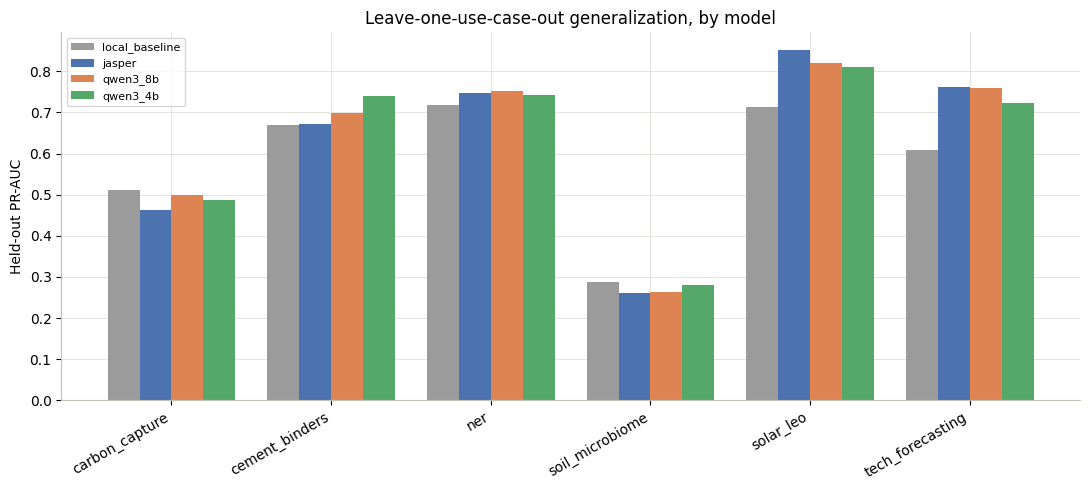

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
models_order = ["local_baseline", "jasper", "qwen3_8b", "qwen3_4b"]
x = np.arange(len(ALL_USE_CASES))
width = 0.2
colors = {"local_baseline": "#9b9b9b", "jasper": "#4c72b0", "qwen3_8b": "#dd8452", "qwen3_4b": "#55a868"}
for i, m in enumerate(models_order):
    vals = [loo_df[(loo_df.model == m) & (loo_df.holdout_use_case == uc)]["holdout_pr_auc"].iloc[0] for uc in ALL_USE_CASES]
    ax.bar(x + (i - 1.5) * width, vals, width, label=m, color=colors[m])
ax.set_xticks(x)
ax.set_xticklabels(ALL_USE_CASES, rotation=30, ha="right")
ax.set_ylabel("Held-out PR-AUC")
ax.set_title("Leave-one-use-case-out generalization, by model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## C. Prediction-level stacking vs. vector concatenation -- jasper+qwen8b vs. jasper+qwen4b

In [7]:
print("Combo variants -- holdout PR-AUC by held-out use case:")
pivot_combo = combo_df.pivot(index="model", columns="holdout_use_case", values="holdout_pr_auc")
pivot_combo["mean"] = pivot_combo.mean(axis=1)
print(pivot_combo.round(3).sort_values("mean", ascending=False).to_string())

print("\nFor reference, solo model means:")
print(pivot_solo["mean"].round(3).to_string())

Combo variants -- holdout PR-AUC by held-out use case:
holdout_use_case              carbon_capture  cement_binders    ner  soil_microbiome  solar_leo  tech_forecasting   mean
model                                                                                                                   
jasper+qwen8b (concat)                 0.488           0.704  0.755            0.270      0.838             0.779  0.639
jasper+qwen4b (concat)                 0.484           0.735  0.747            0.273      0.830             0.750  0.636
jasper+qwen4b (pred-avg)               0.475           0.718  0.747            0.268      0.832             0.749  0.632
jasper+qwen4b (pred-stacked)           0.481           0.737  0.746            0.273      0.821             0.732  0.632
jasper+qwen8b (pred-stacked)           0.491           0.697  0.752            0.266      0.825             0.762  0.632
jasper+qwen8b (pred-avg)               0.479           0.684  0.750            0.260      0.839   

## D. Calibration under a simulated ~50-label budget (`wf_ensemble_report.md` §4)

In [8]:
print("Mean effect of calibration across all 6 holdout use cases (F2 / Brier; ROC-AUC shown to confirm rank-invariance):")
calib_summary = calib_df.groupby("model")[
    ["uncal_f2", "iso_f2", "platt_f2", "uncal_brier", "iso_brier", "platt_brier",
     "uncal_rocauc", "iso_rocauc", "platt_rocauc"]
].mean()
print(calib_summary.round(4).to_string())

max_rocauc_drift = (calib_df[["uncal_rocauc", "iso_rocauc", "platt_rocauc"]].max(axis=1)
                     - calib_df[["uncal_rocauc", "iso_rocauc", "platt_rocauc"]].min(axis=1)).max()
print(f"\nMax ROC-AUC drift from calibration across all rows: {max_rocauc_drift:.4f} "
      "(expected small -- isotonic/Platt are monotonic transforms, so ranking shouldn't change much; "
      "nonzero values here reflect real noise from the tiny ~50-row calibration fit, biggest for Platt).")

Mean effect of calibration across all 6 holdout use cases (F2 / Brier; ROC-AUC shown to confirm rank-invariance):
                        uncal_f2  iso_f2  platt_f2  uncal_brier  iso_brier  platt_brier  uncal_rocauc  iso_rocauc  platt_rocauc
model                                                                                                                          
jasper                    0.1206  0.4701    0.5137       0.2783     0.2559       0.2487        0.5781      0.5508        0.5781
jasper+qwen4b (concat)    0.0840  0.5621    0.5490       0.3336     0.2406       0.2484        0.6036      0.5936        0.5942
jasper+qwen8b (concat)    0.0692  0.5463    0.5230       0.3291     0.2463       0.2482        0.6008      0.5785        0.6008
qwen3_4b                  0.0933  0.7009    0.5597       0.3170     0.2418       0.2491        0.6033      0.6000        0.5786
qwen3_8b                  0.0735  0.7707    0.5137       0.3145     0.2419       0.2488        0.5963      0.5831     

## Findings

In [9]:
print("Does the Jasper/qwen3 win generalize beyond tech_forecasting?")
print(pivot_solo.round(3).to_string())
print()
best_combo_name = pivot_combo["mean"].idxmax()
print(f"Best combo overall (by mean held-out PR-AUC across all 6 holdouts): {best_combo_name} ({pivot_combo['mean'].max():.3f})")
print(f"  vs. best solo model: {pivot_solo['mean'].idxmax()} ({pivot_solo['mean'].max():.3f})")
print()
print("jasper+qwen8b vs. jasper+qwen4b, concat method specifically:")
concat_rows = pivot_combo.loc[[i for i in pivot_combo.index if "concat" in i], "mean"]
print(concat_rows.round(3).sort_values(ascending=False).to_string())
print()
f2_lift = (calib_summary["iso_f2"] - calib_summary["uncal_f2"]).round(3)
brier_change = (calib_summary["iso_brier"] - calib_summary["uncal_brier"]).round(4)
print("Isotonic calibration's effect on F2 (positive = improvement) and Brier (negative = improvement),")
print("across every solo model + both Jasper combos:")
print(pd.DataFrame({"f2_lift": f2_lift, "brier_change": brier_change}).sort_values("f2_lift", ascending=False).to_string())

Does the Jasper/qwen3 win generalize beyond tech_forecasting?
holdout_use_case  carbon_capture  cement_binders    ner  soil_microbiome  solar_leo  tech_forecasting   mean
model                                                                                                       
jasper                     0.464           0.671  0.747            0.261      0.852             0.761  0.626
local_baseline             0.512           0.670  0.719            0.287      0.713             0.608  0.585
qwen3_4b                   0.488           0.739  0.743            0.280      0.811             0.724  0.631
qwen3_8b                   0.499           0.697  0.752            0.264      0.819             0.758  0.632

Best combo overall (by mean held-out PR-AUC across all 6 holdouts): jasper+qwen8b (concat) (0.639)
  vs. best solo model: qwen3_8b (0.632)

jasper+qwen8b vs. jasper+qwen4b, concat method specifically:
model
jasper+qwen8b (concat)    0.639
jasper+qwen4b (concat)    0.636

Isotonic ca